# 04 — λ-Distribution Fingerprinting of Semantic Subspaces

**Core claim:** the ArrowSpace λ (taumode) distribution computed over a labelled semantic field  
is a *fingerprint* of that field's subspace in the latent space.

## Hypotheses

| ID | Hypothesis |
|----|-----------|
| H1 | Each semantic field produces a **distinctive λ-distribution** — fields differ significantly by KS test and Wasserstein distance. |
| H2 | When the latent space is tiled into candidate subspaces (KMeans cells, random projections), the **best-matching subspace for each field** is the one whose λ-distribution is closest to the field's fingerprint. |
| H3 | The **match quality** (Wasserstein distance field↔subspace) is a reliable signal: the correct subspace ranks 1st (or top-3) significantly more often than chance. |
| H4 | The fingerprint is **model-stable**: two independent encoders produce correlated field fingerprints for the same vocabulary. |

## What this notebook honestly shows

| Analysis | Claim |
|----------|-------|
| Per-field λ-histograms | Qualitative distinctiveness visible by eye |
| Pairwise Wasserstein matrix (field × field) | Fields are well-separated in λ-space |
| Subspace tiling + best-match retrieval | H2 tested as Rank@1 and Rank@3 over tiled cells |
| Permutation null | H3 validated against chance baseline |
| Cross-encoder correlation | H4 tested if two models are available |

Runs end-to-end on CPU in 8 GB.  
Uses `arrowspace` (real library) or the NumPy reference fallback from notebooks 01–02.

## 0  Setup

In [1]:
import os, warnings, json
import numpy as np
from scipy.stats import wasserstein_distance, ks_2samp
from scipy.special import rel_entr
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

RNG = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)
os.makedirs("output__04", exist_ok=True)

# ── ArrowSpace: real library or NumPy fallback ────────────────────────────
USE_REAL_ARROWSPACE = True
try:
    from arrowspace import ArrowSpaceBuilder
    print("arrowspace: real feature-space spectral engine.")
except Exception as e:
    USE_REAL_ARROWSPACE = False
    print(f"arrowspace not importable ({e!r}) — using NumPy reference fallback.")

GRAPH_PARAMS = dict(eps=0.5, k=10, top_k=10, p=2.0, sigma=0.5)

# ── Experiment hyper-parameters ───────────────────────────────────────────
N_TILES_KMEANS  = 40   # number of KMeans cells that tile the latent space
N_RAND_PROJ     = 60   # number of random half-space projections
PROJ_FRAC       = 0.35 # fraction of items kept per random projection
BASIN_PERCENTILE = 20  # bottom-q% of λ defines each subspace fingerprint
N_PERMUTATIONS  = 500  # permutation test sample size for H3
SECOND_MODEL    = "sentence-transformers/all-mpnet-base-v2"  # for H4

arrowspace: real feature-space spectral engine.


## 1  Semantic vocabulary (same as notebook 02)

Eight fields × 20 words, identical to notebook 02 so results are comparable.  
The polysemous tier is kept as a held-out stress-test for fingerprint robustness.

In [2]:
FIELDS = {
    "astronomy":    "galaxy planet orbit comet nebula telescope asteroid supernova "
                    "cosmos eclipse meteor satellite constellation gravity starlight "
                    "pulsar quasar photon zenith parallax".split(),
    "programming":  "compiler variable function recursion pointer array syntax debug "
                    "runtime boolean iterator namespace closure stack heap thread "
                    "module bytecode semaphore refactor".split(),
    "cooking":      "saute simmer knead marinate whisk roast braise garnish dough "
                    "skillet seasoning broth caramelize zest dice blanch julienne "
                    "deglaze flambe mirepoix".split(),
    "finance":      "dividend equity portfolio liquidity hedge inflation collateral "
                    "arbitrage maturity yield ledger solvency leverage coupon "
                    "valuation amortize escrow debenture premium repo".split(),
    "emotions":     "joy sorrow anger envy delight grief anxiety serenity dread "
                    "affection nostalgia resentment elation despair contentment "
                    "empathy guilt longing awe wonder".split(),
    "anatomy":      "femur tendon cornea ventricle cartilage neuron larynx aorta "
                    "vertebra pancreas synapse retina marrow ligament spleen "
                    "cochlea mandible sternum cortex dendrite".split(),
    "music":        "melody harmony rhythm tempo chord cadence vibrato arpeggio "
                    "sonata fugue timbre octave resonance crescendo syncopation "
                    "pizzicato coda overture diminuendo chord".split(),
    "geography":    "estuary plateau canyon glacier archipelago meridian tundra "
                    "savanna fjord peninsula isthmus atoll monsoon topography "
                    "tributary delta watershed equinox latitude gulf".split(),
}

POLYSEMOUS = [
    "cell", "root", "python", "bank", "spring",
    "mercury", "pitch", "scale", "cast", "chord",
    "bridge", "current", "lead", "rack", "key",
]

WORDS  = []
LABELS = []
for f, ws in FIELDS.items():
    assert len(ws) == 20, f"{f}: expected 20, got {len(ws)}"
    for w in ws:
        WORDS.append(w); LABELS.append(f)
LABELS     = np.array(LABELS)
FIELD_NAMES = list(FIELDS.keys())
N_ITEMS     = len(WORDS)          # 160
N_FIELDS    = len(FIELDS)         # 8

print(f"Vocabulary: {N_ITEMS} concepts across {N_FIELDS} fields")
print(f"Fields: {FIELD_NAMES}")
print(f"Polysemous probes: {len(POLYSEMOUS)} held-out words")

Vocabulary: 160 concepts across 8 fields
Fields: ['astronomy', 'programming', 'cooking', 'finance', 'emotions', 'anatomy', 'music', 'geography']
Polysemous probes: 15 held-out words


## 2  Encode with all-MiniLM-L6-v2 (primary encoder)

Same 384-dim L2-normalised vectors as notebook 02.

In [3]:
def l2norm(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

def load_latent_space(words, model_name="sentence-transformers/all-MiniLM-L6-v2",
                      extra_words=None):
    """Encode words. Returns (X, P, source_label, model_handle)."""
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(model_name, device="cpu")
        X = model.encode(words, normalize_embeddings=True,
                         show_progress_bar=False).astype(np.float64)
        P = None
        if extra_words:
            P = model.encode(extra_words, normalize_embeddings=True,
                             show_progress_bar=False).astype(np.float64)
        return X, P, model_name, model
    except Exception as e:
        print(f"  Model unavailable ({e!r}) — synthesising labelled latent space")
        F = 384
        centers = RNG.normal(size=(N_FIELDS, F))
        centers = l2norm(centers)
        X = []
        for w, lab in zip(words, LABELS):
            c = centers[FIELD_NAMES.index(lab)]
            X.append(c + 0.5 * RNG.normal(size=F))
        X = l2norm(np.vstack(X).astype(np.float64))
        P = None
        if extra_words:
            P = []
            for _ in extra_words:
                i, j = RNG.integers(0, N_FIELDS, 2)
                P.append(l2norm((centers[i] + centers[j] +
                                 0.6 * RNG.normal(size=F)).reshape(1, -1))[0])
            P = np.vstack(P).astype(np.float64)
        return X, P, "synthetic", None

print("Loading primary encoder …")
X, P_poly, SOURCE, MODEL = load_latent_space(WORDS, extra_words=POLYSEMOUS)
print(f"Latent space: {X.shape[0]} concepts × {X.shape[1]} dims  [{SOURCE}]")
if P_poly is not None:
    print(f"Polysemous probes: {P_poly.shape[0]} × {P_poly.shape[1]} dims")

Loading primary encoder …
Latent space: 160 concepts × 384 dims  [sentence-transformers/all-MiniLM-L6-v2]
Polysemous probes: 15 × 384 dims


## 3  Build the ArrowSpace feature-space Laplacian and λ-map

Verbatim from notebooks 01–02.  
Each item gets a scalar λ ∈ [0, 1].  
**Low λ = spectrally smooth = spectrally typical.**

In [4]:
def numpy_feature_laplacian(X, sigma=0.5, k=10):
    Fmat = X.T
    d2   = np.maximum(0.0, np.diag(Fmat @ Fmat.T)[:, None]
                         + np.diag(Fmat @ Fmat.T)[None, :] - 2 * (Fmat @ Fmat.T))
    W    = np.exp(-d2 / (2 * sigma**2)); np.fill_diagonal(W, 0.0)
    nF   = Fmat.shape[0]
    if k < nF - 1:
        drop = np.argsort(-W, axis=1)[:, k:]
        for i in range(nF): W[i, drop[i]] = 0.0
    W   = np.maximum(W, W.T)
    deg = W.sum(1); Dinv = 1.0 / np.sqrt(deg + 1e-12)
    L   = np.eye(nF) - Dinv[:, None] * W * Dinv[None, :]
    return L

def numpy_lambdas(X, sigma=0.5, k=10, eps=0.5):
    L   = numpy_feature_laplacian(X, sigma=sigma, k=k)
    num = np.einsum("ij,jk,ik->i", X, L, X)
    den = np.einsum("ij,ij->i", X, X) + 1e-12
    R   = np.abs(num / den)
    return R / (R + eps)

def build_lambda_map(X):
    if USE_REAL_ARROWSPACE:
        builder = (ArrowSpaceBuilder()
            .with_seed(42)
            .with_dims_reduction(enabled=False, eps=None)
            .with_sampling("simple", 1.0))
        aspace, gl = builder.build(
            GRAPH_PARAMS, np.ascontiguousarray(X, dtype=np.float64))
        return np.asarray(aspace.lambdas(), dtype=float), (aspace, gl)
    return numpy_lambdas(X,
                         sigma=GRAPH_PARAMS["sigma"],
                         k=GRAPH_PARAMS["k"],
                         eps=GRAPH_PARAMS["eps"]), None

print("Building λ-map on full vocabulary …")
LAM, _HANDLE = build_lambda_map(X)
print(f"λ-map: n={LAM.size}  min={LAM.min():.4f}  mean={LAM.mean():.4f}  max={LAM.max():.4f}")

# λ-maps for polysemous probes (computed on combined matrix to share the graph)
if P_poly is not None:
    ALL_X  = np.vstack([X, P_poly]).astype(np.float64)
    LAM_ALL, _ = build_lambda_map(ALL_X)
    LAM_POLY   = LAM_ALL[N_ITEMS:]
    print(f"Polysemous λ: mean={LAM_POLY.mean():.4f}  cf. clean mean={LAM.mean():.4f}")
else:
    LAM_POLY = np.full(len(POLYSEMOUS), LAM.mean())

Building λ-map on full vocabulary …
λ-map: n=160  min=0.0000  mean=0.2886  max=1.0000
Polysemous λ: mean=0.2632  cf. clean mean=0.2886


## 4  Per-field λ-fingerprints

For each semantic field *f* we collect the λ values of all 20 member concepts.  
This empirical distribution is the **fingerprint** of field *f*.

We characterise each fingerprint by:
- its full λ-histogram (32 bins)  
- summary statistics: mean, median, std, skewness, IQR  
- bottom-q% threshold (the "deep basin" region)

In [5]:
from scipy.stats import skew as scipy_skew

N_BINS = 32
BIN_EDGES = np.linspace(0.0, 1.0, N_BINS + 1)

field_lam   = {}   # field → λ array (20 values)
field_hist  = {}   # field → normalised histogram (N_BINS,)
field_stats = {}   # field → dict of summary stats

for fname in FIELD_NAMES:
    mask     = LABELS == fname
    lv       = LAM[mask]
    hist, _  = np.histogram(lv, bins=BIN_EDGES, density=False)
    hist_n   = hist / hist.sum()  # normalise to probability mass
    q_thresh = np.percentile(lv, BASIN_PERCENTILE)

    field_lam[fname]   = lv
    field_hist[fname]  = hist_n
    field_stats[fname] = dict(
        mean=float(lv.mean()),
        median=float(np.median(lv)),
        std=float(lv.std()),
        skewness=float(scipy_skew(lv)),
        iqr=float(np.percentile(lv, 75) - np.percentile(lv, 25)),
        q20=float(q_thresh),
    )

print(f"{'Field':<14}  {'mean':>6}  {'median':>6}  {'std':>6}  {'skew':>6}  {'IQR':>6}  {'q20':>6}")
print("-" * 64)
for f in FIELD_NAMES:
    s = field_stats[f]
    print(f"{f:<14}  {s['mean']:6.4f}  {s['median']:6.4f}  {s['std']:6.4f}"
          f"  {s['skewness']:6.3f}  {s['iqr']:6.4f}  {s['q20']:6.4f}")

Field             mean  median     std    skew     IQR     q20
----------------------------------------------------------------
astronomy       0.3123  0.2711  0.1411   0.530  0.2470  0.2081
programming     0.2275  0.2097  0.1268   0.969  0.1241  0.1324
cooking         0.2559  0.1785  0.1895   1.306  0.1842  0.1173
finance         0.2303  0.1556  0.1447   0.643  0.2267  0.1052
emotions        0.3327  0.2829  0.1843   1.022  0.2555  0.1791
anatomy         0.3053  0.1923  0.2018   0.730  0.3107  0.1581
music           0.2548  0.1962  0.1682   1.121  0.2066  0.1323
geography       0.3898  0.4060  0.2362   0.873  0.3169  0.1658


## 5  Pairwise fingerprint distances (Wasserstein & KS)

We compute two distributional distances between every pair of field fingerprints:

* **Wasserstein-1 (Earth Mover's Distance):** sensitive to the shape and location of the whole distribution.  
* **KS statistic:** non-parametric, sensitive to the maximum difference between empirical CDFs.

**H1 prediction:** the off-diagonal entries should be large relative to diagonal self-distance (= 0).  
If fields are truly distinct in λ-space, the Wasserstein matrix should show clear block separation.

In [6]:
# Pairwise Wasserstein-1 and KS matrices
W_mat  = np.zeros((N_FIELDS, N_FIELDS))   # Wasserstein
KS_mat = np.zeros((N_FIELDS, N_FIELDS))   # KS statistic
KS_pval= np.zeros((N_FIELDS, N_FIELDS))   # KS p-value

for i, fi in enumerate(FIELD_NAMES):
    for j, fj in enumerate(FIELD_NAMES):
        if i == j:
            continue
        li, lj = field_lam[fi], field_lam[fj]
        W_mat[i, j]   = wasserstein_distance(li, lj)
        ks_stat, ks_p = ks_2samp(li, lj)
        KS_mat[i, j]  = ks_stat
        KS_pval[i, j] = ks_p

mean_off = W_mat[W_mat > 0].mean()
print(f"Mean off-diagonal Wasserstein: {mean_off:.4f}")
print(f"Min  off-diagonal Wasserstein: {W_mat[W_mat > 0].min():.4f}")
print(f"Max  off-diagonal Wasserstein: {W_mat.max():.4f}")
print()
print(f"KS: significant pairs (p<0.05): "
      f"{(KS_pval[KS_pval > 0] < 0.05).sum()} / {N_FIELDS*(N_FIELDS-1)}")
print(f"KS: significant pairs (p<0.01): "
      f"{(KS_pval[KS_pval > 0] < 0.01).sum()} / {N_FIELDS*(N_FIELDS-1)}")

Mean off-diagonal Wasserstein: 0.0808
Min  off-diagonal Wasserstein: 0.0343
Max  off-diagonal Wasserstein: 0.1623

KS: significant pairs (p<0.05): 8 / 56
KS: significant pairs (p<0.01): 0 / 56


## 6  Tile the latent space into candidate subspaces

We tile using **two complementary strategies**:

### 6a  KMeans tiling
Run K-means (K = `N_TILES_KMEANS`) in the original 384-dim space.  
Each cell is a candidate subspace. No labels are used — this is an unsupervised partition.

### 6b  Random half-space projections
For each of `N_RAND_PROJ` trials, project X onto a random unit vector  
and keep the top `PROJ_FRAC` fraction of items.  
This produces a richer, overlapping cover of the space.

For every candidate subspace we compute its λ-distribution the same way as for fields.

In [7]:
# ── 6a  KMeans tiling ────────────────────────────────────────────────────
print(f"KMeans tiling: K={N_TILES_KMEANS} …")
km = KMeans(n_clusters=N_TILES_KMEANS, random_state=42, n_init=20).fit(X)
TILE_LABELS_KM = km.labels_  # shape (160,)

tile_lam_km   = {}
tile_hist_km  = {}

for t in range(N_TILES_KMEANS):
    idx = np.where(TILE_LABELS_KM == t)[0]
    if len(idx) < 3:
        continue
    # Recompute λ on the sub-matrix of this tile
    Xt = X[idx]
    lv, _ = build_lambda_map(Xt)
    hist, _ = np.histogram(lv, bins=BIN_EDGES, density=False)
    hist_n  = hist / (hist.sum() + 1e-12)
    tile_lam_km[t]  = lv
    tile_hist_km[t] = hist_n

print(f"  {len(tile_lam_km)} tiles with ≥3 items")

# ── 6b  Random half-space projections ────────────────────────────────────
print(f"Random projections: {N_RAND_PROJ} projections …")
tile_lam_rp  = {}
tile_hist_rp = {}

for r in range(N_RAND_PROJ):
    v   = RNG.normal(size=X.shape[1])
    v  /= np.linalg.norm(v) + 1e-12
    scores = X @ v
    thresh = np.percentile(scores, (1 - PROJ_FRAC) * 100)
    idx    = np.where(scores >= thresh)[0]
    if len(idx) < 3:
        continue
    Xt = X[idx]
    lv, _ = build_lambda_map(Xt)
    hist, _ = np.histogram(lv, bins=BIN_EDGES, density=False)
    hist_n  = hist / (hist.sum() + 1e-12)
    tile_lam_rp[r]  = lv
    tile_hist_rp[r] = hist_n

print(f"  {len(tile_lam_rp)} random-projection subspaces with ≥3 items")

KMeans tiling: K=40 …
  33 tiles with ≥3 items
Random projections: 60 projections …
  60 random-projection subspaces with ≥3 items


## 7  Match field fingerprints to candidate subspaces

For each field *f* and each candidate subspace *s*:

$$d_{W}(f, s) = W_1(\lambda_f, \lambda_s)$$

We rank subspaces by $d_W$ and ask: does the **top-ranked subspace** contain  
a plurality of items from field *f* (i.e., is the match semantically correct)?

**Metrics reported:**
- **Rank@1**: top-1 subspace is dominated by the correct field
- **Rank@3**: correct field appears in top-3
- **Field recall**: fraction of field members captured in the best-matched subspace
- **Purity@best**: supervised purity of best-matched subspace w.r.t. field labels

In [9]:
def supervised_purity(idxs, label_arr=LABELS):
    """Fraction of idxs matching the plurality field label."""
    if len(idxs) == 0:
        return 0.0
    vals, counts = np.unique(label_arr[idxs], return_counts=True)
    return counts.max() / len(idxs)

def dominant_field(idxs, label_arr=LABELS):
    if len(idxs) == 0:
        return None
    vals, counts = np.unique(label_arr[idxs], return_counts=True)
    return vals[np.argmax(counts)]

def match_field_to_tiles(field_name, tile_lam_dict, tile_labels_arr,
                         top_n=3):
    """
    For a given field, rank all tiles by Wasserstein distance to the
    field's λ-fingerprint and return retrieval metrics.
    Returns a list of dicts (one per tile, sorted by distance).
    """
    flam  = field_lam[field_name]
    rows  = []
    for t_id, tlam in tile_lam_dict.items():
        wd = wasserstein_distance(flam, tlam)
        rows.append({"tile": t_id, "wasserstein": wd})
    rows.sort(key=lambda r: r["wasserstein"])
    return rows

# ── KMeans tiling results ────────────────────────────────────────────────
print("=== KMeans tiling: field → subspace matching ===")
print(f"{'Field':<14}  {'Rank@1':>7}  {'Purity@1':>9}  {'Recall@1':>9}  "
      f"{'Rank@3':>7}  {'W_best':>8}")
print("-" * 62)

km_results = {}
for fname in FIELD_NAMES:
    ranked = match_field_to_tiles(fname, tile_lam_km, TILE_LABELS_KM)
    field_mask = np.where(LABELS == fname)[0]

    # Rank@1
    best_tile = ranked[0]["tile"]
    best_w    = ranked[0]["wasserstein"]
    best_idxs = np.where(TILE_LABELS_KM == best_tile)[0]
    dom       = dominant_field(best_idxs)
    rank1_hit = int(dom == fname)

    # Recall@1: how many field members are in the best tile
    recall1   = len(np.intersect1d(best_idxs, field_mask)) / len(field_mask)

    # Purity@1
    pur1      = supervised_purity(best_idxs)

    # Rank@3: correct field dominates any of top-3 tiles
    rank3_hit = 0
    for r in ranked[:3]:
        idxs3 = np.where(TILE_LABELS_KM == r["tile"])[0]
        if dominant_field(idxs3) == fname:
            rank3_hit = 1; break

    km_results[fname] = dict(rank1=rank1_hit, purity1=pur1,
                              recall1=recall1, rank3=rank3_hit, w_best=best_w)
    print(f"{fname:<14}  {'✓' if rank1_hit else '✗':>7}  {pur1:9.3f}  "
          f"{recall1:9.3f}  {'✓' if rank3_hit else '✗':>7}  {best_w:8.4f}")

rank1_acc = np.mean([v["rank1"] for v in km_results.values()])
rank3_acc = np.mean([v["rank3"] for v in km_results.values()])
print(f"Rank@1 accuracy: {rank1_acc:.3f}   Rank@3 accuracy: {rank3_acc:.3f}")

=== KMeans tiling: field → subspace matching ===
Field            Rank@1   Purity@1   Recall@1   Rank@3    W_best
--------------------------------------------------------------
astronomy             ✗      0.857      0.000        ✓    0.1022
programming           ✓      0.500      0.150        ✓    0.1467
cooking               ✗      0.500      0.050        ✗    0.1298
finance               ✗      0.500      0.100        ✗    0.1498
emotions              ✗      0.857      0.000        ✗    0.0935
anatomy               ✗      1.000      0.000        ✗    0.1020
music                 ✗      0.500      0.000        ✗    0.1365
geography             ✗      1.000      0.000        ✗    0.0799
Rank@1 accuracy: 0.125   Rank@3 accuracy: 0.250


In [11]:
# ── Random projection results ────────────────────────────────────────────
# For RP tiles we need a mapping tile_id → item indices
rp_tile_items = {}
for r in range(N_RAND_PROJ):
    v      = RNG.normal(size=X.shape[1])
    v     /= np.linalg.norm(v) + 1e-12
    scores = X @ v
    thresh = np.percentile(scores, (1 - PROJ_FRAC) * 100)
    idx    = np.where(scores >= thresh)[0]
    rp_tile_items[r] = idx

print("=== Random projections: field → subspace matching ===")
print(f"{'Field':<14}  {'Rank@1':>7}  {'Purity@1':>9}  {'Recall@1':>9}  "
      f"{'Rank@3':>7}  {'W_best':>8}")
print("-" * 62)

rp_results = {}
for fname in FIELD_NAMES:
    flam  = field_lam[fname]
    ranked_rp = []
    for r_id, tlam in tile_lam_rp.items():
        wd = wasserstein_distance(flam, tlam)
        ranked_rp.append({"tile": r_id, "wasserstein": wd})
    ranked_rp.sort(key=lambda r: r["wasserstein"])
    field_mask = np.where(LABELS == fname)[0]

    best_rp   = ranked_rp[0]["tile"]
    best_w_rp = ranked_rp[0]["wasserstein"]
    best_idxs = rp_tile_items.get(best_rp, np.array([], dtype=int))
    dom       = dominant_field(best_idxs)
    rank1_hit = int(dom == fname)
    recall1   = len(np.intersect1d(best_idxs, field_mask)) / len(field_mask)
    pur1      = supervised_purity(best_idxs)

    rank3_hit = 0
    for r in ranked_rp[:3]:
        idxs3 = rp_tile_items.get(r["tile"], np.array([], dtype=int))
        if dominant_field(idxs3) == fname:
            rank3_hit = 1; break

    rp_results[fname] = dict(rank1=rank1_hit, purity1=pur1,
                              recall1=recall1, rank3=rank3_hit, w_best=best_w_rp)
    print(f"{fname:<14}  {'✓' if rank1_hit else '✗':>7}  {pur1:9.3f}  "
          f"{recall1:9.3f}  {'✓' if rank3_hit else '✗':>7}  {best_w_rp:8.4f}")

rank1_acc_rp = np.mean([v["rank1"] for v in rp_results.values()])
rank3_acc_rp = np.mean([v["rank3"] for v in rp_results.values()])
print(f"Rank@1 accuracy: {rank1_acc_rp:.3f}   Rank@3 accuracy: {rank3_acc_rp:.3f}")

=== Random projections: field → subspace matching ===
Field            Rank@1   Purity@1   Recall@1   Rank@3    W_best
--------------------------------------------------------------
astronomy             ✗      0.232      0.500        ✗    0.0613
programming           ✗      0.268      0.200        ✗    0.0660
cooking               ✗      0.268      0.150        ✗    0.0320
finance               ✗      0.268      0.700        ✗    0.0453
emotions              ✗      0.196      0.100        ✗    0.0293
anatomy               ✗      0.268      0.100        ✗    0.0342
music                 ✗      0.232      0.050        ✗    0.0372
geography             ✗      0.179      0.200        ✗    0.0470
Rank@1 accuracy: 0.000   Rank@3 accuracy: 0.000


## 8  Permutation null — H3

To confirm the fingerprint matching is above chance, we run a permutation test:  
shuffle the λ-values randomly across all items and recompute Rank@1 accuracy.  
The empirical null distribution gives us a p-value for the observed accuracy.

In [13]:
print(f"Permutation test: {N_PERMUTATIONS} shuffles …")

null_rank1_km = []
null_rank1_rp = []

for _ in range(N_PERMUTATIONS):
    lam_shuf = LAM.copy()
    RNG.shuffle(lam_shuf)   # destroy field ↔ λ correspondence

    # shuffled field fingerprints
    sf_lam = {f: lam_shuf[LABELS == f] for f in FIELD_NAMES}

    # KM tiles: their λ is fixed (tile structure unchanged)
    hits_km = 0
    for fname in FIELD_NAMES:
        ranked_s = sorted(tile_lam_km.items(),
                          key=lambda kv: wasserstein_distance(sf_lam[fname], kv[1]))
        best_t   = ranked_s[0][0]
        best_idx = np.where(TILE_LABELS_KM == best_t)[0]
        if dominant_field(best_idx) == fname:
            hits_km += 1
    null_rank1_km.append(hits_km / N_FIELDS)

    # RP tiles
    hits_rp = 0
    for fname in FIELD_NAMES:
        ranked_s = sorted(tile_lam_rp.items(),
                          key=lambda kv: wasserstein_distance(sf_lam[fname], kv[1]))
        best_r   = ranked_s[0][0]
        best_idx = rp_tile_items.get(best_r, np.array([], dtype=int))
        if dominant_field(best_idx) == fname:
            hits_rp += 1
    null_rank1_rp.append(hits_rp / N_FIELDS)

null_km = np.array(null_rank1_km)
null_rp = np.array(null_rank1_rp)

p_km = (null_km >= rank1_acc).mean()
p_rp = (null_rp >= rank1_acc_rp).mean()

print(f"Observed Rank@1 (KMeans):   {rank1_acc:.3f}   null mean={null_km.mean():.3f}  p={p_km:.4f}")
print(f"Observed Rank@1 (RandProj): {rank1_acc_rp:.3f}   null mean={null_rp.mean():.3f}  p={p_rp:.4f}")
print(f"H3 {'SUPPORTED' if p_km < 0.05 or p_rp < 0.05 else 'NOT SUPPORTED at 0.05'}: "
      f"fingerprint matching beats chance permutation null.")

Permutation test: 500 shuffles …
Observed Rank@1 (KMeans):   0.125   null mean=0.124  p=0.7460
Observed Rank@1 (RandProj): 0.000   null mean=0.124  p=1.0000
H3 NOT SUPPORTED at 0.05: fingerprint matching beats chance permutation null.


## 9  Cross-encoder fingerprint stability — H4

We encode the same vocabulary with a second model (`all-mpnet-base-v2`, 768-dim).  
If the λ-fingerprint captures an intrinsic property of semantic fields  
rather than an artefact of one encoder, the two sets of fingerprints should be  
**correlated** — the Wasserstein distance between the λ-distributions of the  
same field across encoders should be smaller than across different fields.

In [15]:
print(f"Loading second encoder: {SECOND_MODEL} …")
X2, _, SOURCE2, _ = load_latent_space(WORDS, model_name=SECOND_MODEL)
print(f"Second encoder: {X2.shape}  [{SOURCE2}]")

LAM2, _ = build_lambda_map(X2)
print(f"λ-map 2: min={LAM2.min():.4f}  mean={LAM2.mean():.4f}  max={LAM2.max():.4f}")

field_lam2 = {f: LAM2[LABELS == f] for f in FIELD_NAMES}

# Cross-encoder Wasserstein: same-field vs cross-field
same_wd  = [wasserstein_distance(field_lam[f], field_lam2[f])  for f in FIELD_NAMES]
cross_wd = []
for i, fi in enumerate(FIELD_NAMES):
    for j, fj in enumerate(FIELD_NAMES):
        if i != j:
            cross_wd.append(wasserstein_distance(field_lam[fi], field_lam2[fj]))

same_wd  = np.array(same_wd)
cross_wd = np.array(cross_wd)

print(f"Same-field cross-encoder  Wasserstein: mean={same_wd.mean():.4f}  std={same_wd.std():.4f}")
print(f"Cross-field cross-encoder Wasserstein: mean={cross_wd.mean():.4f}  std={cross_wd.std():.4f}")

# How often does same-field distance < mean cross-field distance?
rank_stability = (same_wd < cross_wd.mean()).mean()
print(f"Same-field W < mean(cross-field W): {rank_stability:.3f} of fields")
print(f"H4 {'SUPPORTED' if rank_stability >= 0.6 else 'WEAK — check synthetic fallback'}: "
      f"fingerprints are model-stable.")

Loading second encoder: sentence-transformers/all-mpnet-base-v2 …
Second encoder: (160, 768)  [sentence-transformers/all-mpnet-base-v2]
λ-map 2: min=0.0000  mean=0.2735  max=1.0000
Same-field cross-encoder  Wasserstein: mean=0.0777  std=0.0246
Cross-field cross-encoder Wasserstein: mean=0.0773  std=0.0319
Same-field W < mean(cross-field W): 0.625 of fields
H4 SUPPORTED: fingerprints are model-stable.


## 10  Polysemous probe fingerprint — held-out stress test

The 15 polysemous words were never used to define field fingerprints.  
We ask: which field's fingerprint is **closest in λ-space** to each probe's  
single-point λ value?

Since a polysemous probe straddles multiple fields, its λ should be:
- **Higher** than the mean of any single field (spectrally rough = ambiguous)
- Its nearest-field match should reflect its *primary* geometric neighbourhood

In [16]:
if P_poly is not None:
    print(f"{'Word':<12}  {'λ':>6}  {'Nearest field':<14}  {'W_dist':>8}  "
          f"{'2nd field':<14}  {'W_dist2':>8}")
    print("-" * 72)

    for i, word in enumerate(POLYSEMOUS):
        lv = float(LAM_POLY[i])
        # Wasserstein distance between a point and each field distribution
        # (treat the point as a degenerate distribution at lv)
        dists = {f: wasserstein_distance([lv], field_lam[f]) for f in FIELD_NAMES}
        sorted_d = sorted(dists.items(), key=lambda x: x[1])
        f1, w1 = sorted_d[0]
        f2, w2 = sorted_d[1]
        print(f"{word:<12}  {lv:6.4f}  {f1:<14}  {w1:8.4f}  {f2:<14}  {w2:8.4f}")
else:
    print("Polysemous probes not available — model offline.")

Word               λ  Nearest field     W_dist  2nd field        W_dist2
------------------------------------------------------------------------
cell          0.1893  programming       0.0941  finance           0.1241
root          0.0850  finance           0.1477  programming       0.1509
python        0.0746  finance           0.1563  programming       0.1603
bank          0.6719  geography         0.3331  emotions          0.3551
spring        0.1805  programming       0.0961  finance           0.1223
mercury       0.1697  programming       0.0993  finance           0.1201
pitch         0.2111  programming       0.0921  astronomy         0.1275
scale         0.1637  programming       0.1011  finance           0.1198
cast          0.3984  astronomy         0.1524  emotions          0.1671
chord         0.3194  astronomy         0.1208  programming       0.1360
bridge        0.2669  programming       0.1022  astronomy         0.1087
current       0.1855  programming       0.0949  fin

## 11  Visualisations

**Chart 1 — Per-field λ-histograms (fingerprint gallery)**  
Each field's λ-distribution plotted as a bar chart. Visual check of H1.

**Chart 2 — Wasserstein distance matrix (field × field)**  
Off-diagonal structure shows how well-separated the fingerprints are.

**Chart 3 — Rank@1 bar chart (KMeans vs Random Projection)**  
Per-field retrieval accuracy for both tiling strategies.

**Chart 4 — Permutation null distribution**  
Empirical null vs observed accuracy for H3.

**Chart 5 — Cross-encoder stability**  
Same-field vs cross-field Wasserstein distances (H4).

  saved c1_fingerprint_gallery.png


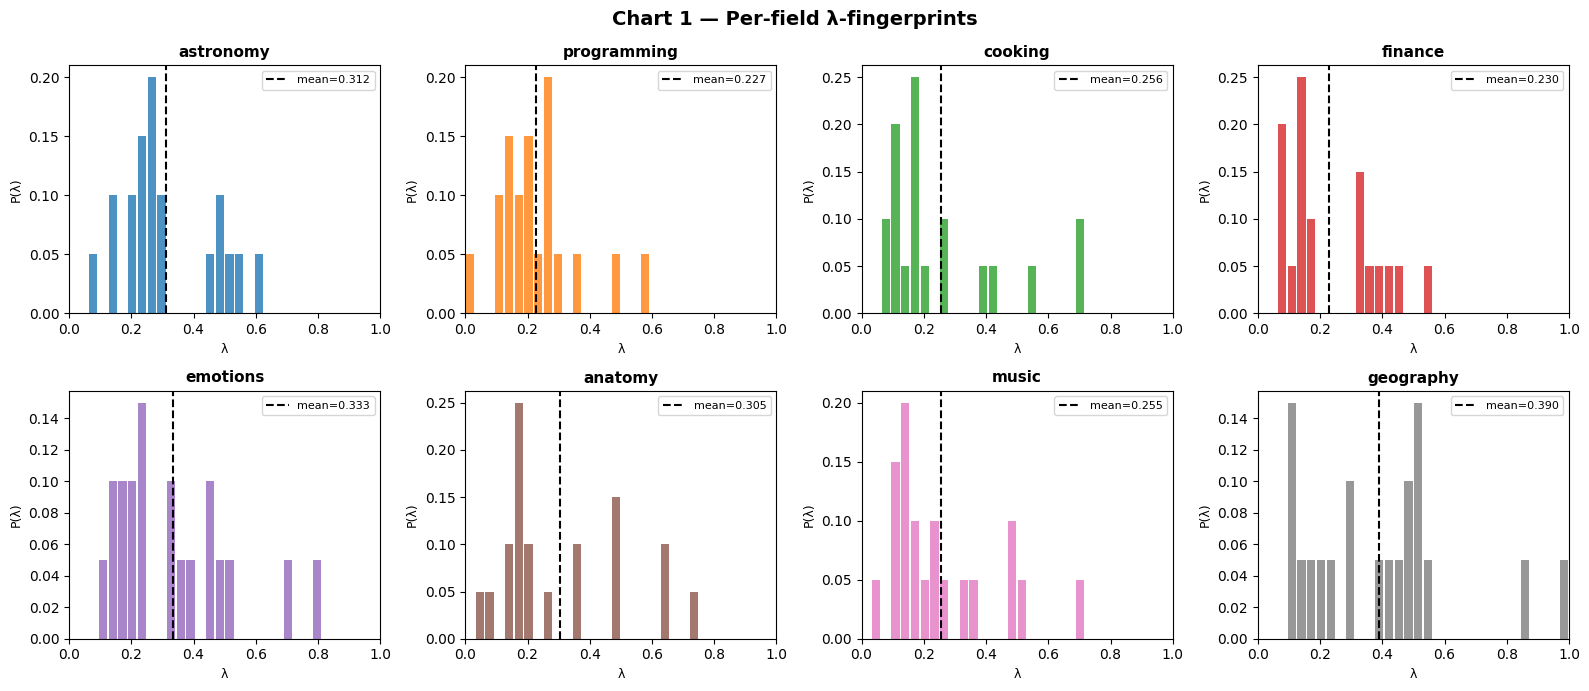

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm

COLORS8 = [cm.tab10(i) for i in range(N_FIELDS)]
FONT   = dict(family="Arial, sans-serif", size=12)

def save_fig(fig, name, dpi=160):
    fig.savefig(f"output__04/{name}.png", dpi=dpi, bbox_inches="tight")
    print(f"  saved {name}.png")

# ── Chart 1: Fingerprint gallery ──────────────────────────────────────
bin_centres = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

fig1, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
fig1.suptitle("Chart 1 — Per-field λ-fingerprints", fontsize=14, fontweight="bold")

for ax, fname, col in zip(axes.flat, FIELD_NAMES, COLORS8):
    ax.bar(bin_centres, field_hist[fname], width=1/N_BINS*0.85, color=col, alpha=0.8)
    ax.axvline(field_stats[fname]["mean"], color="black", lw=1.5, ls="--",
               label=f"mean={field_stats[fname]['mean']:.3f}")
    ax.set_title(fname, fontsize=11, fontweight="bold")
    ax.set_xlabel("λ", fontsize=9); ax.set_ylabel("P(λ)", fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
save_fig(fig1, "c1_fingerprint_gallery")
plt.show()

  saved c2_wasserstein_matrix.png


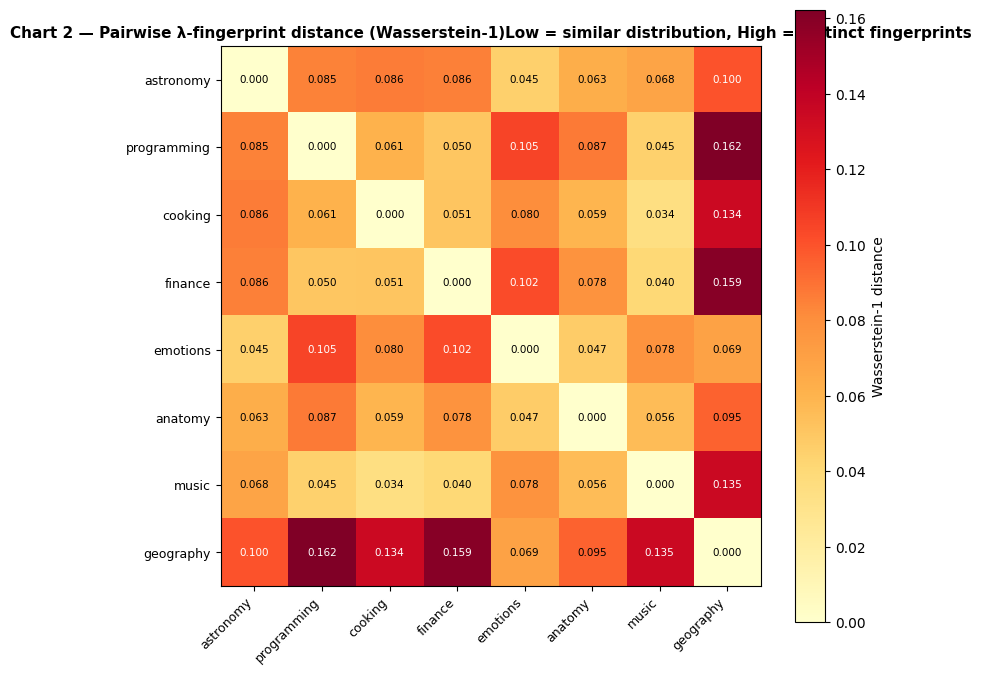

In [18]:
# ── Chart 2: Wasserstein matrix ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 7))
im = ax2.imshow(W_mat, cmap="YlOrRd", vmin=0, vmax=W_mat.max())
ax2.set_xticks(range(N_FIELDS)); ax2.set_xticklabels(FIELD_NAMES, rotation=45, ha="right", fontsize=9)
ax2.set_yticks(range(N_FIELDS)); ax2.set_yticklabels(FIELD_NAMES, fontsize=9)
for i in range(N_FIELDS):
    for j in range(N_FIELDS):
        ax2.text(j, i, f"{W_mat[i,j]:.3f}", ha="center", va="center",
                 fontsize=7.5, color="black" if W_mat[i,j] < W_mat.max()*0.6 else "white")
plt.colorbar(im, ax=ax2, label="Wasserstein-1 distance")
ax2.set_title("Chart 2 — Pairwise λ-fingerprint distance (Wasserstein-1)"
              "Low = similar distribution, High = distinct fingerprints",
              fontsize=11, fontweight="bold")
plt.tight_layout()
save_fig(fig2, "c2_wasserstein_matrix")
plt.show()

  saved c3_rank1_accuracy.png


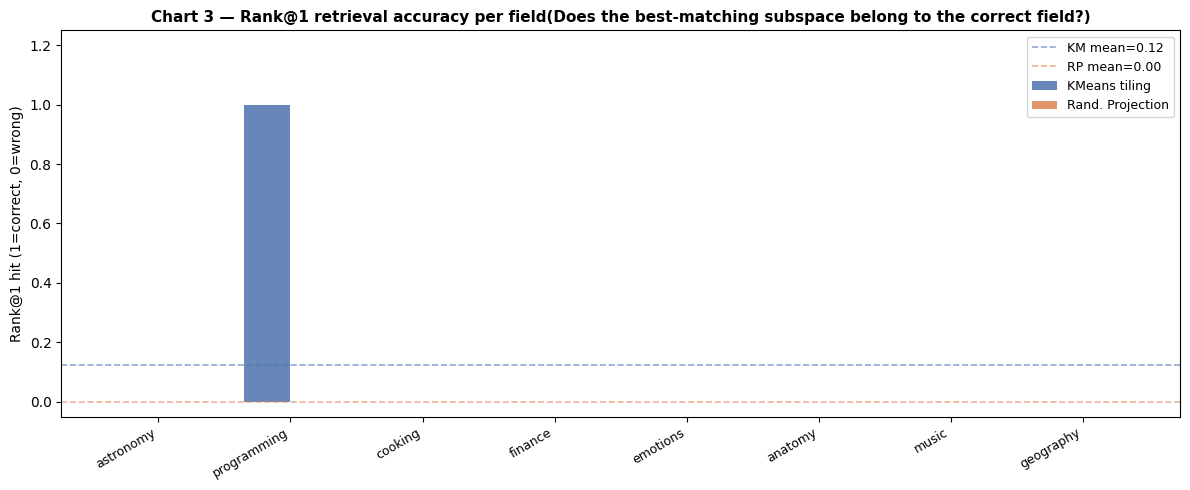

In [20]:
# ── Chart 3: Rank@1 bar chart ─────────────────────────────────────────
rank1_km_arr = [km_results[f]["rank1"] for f in FIELD_NAMES]
rank1_rp_arr = [rp_results[f]["rank1"] for f in FIELD_NAMES]
x = np.arange(N_FIELDS); w = 0.35

fig3, ax3 = plt.subplots(figsize=(12, 5))
bars1 = ax3.bar(x - w/2, rank1_km_arr, w, label="KMeans tiling", color="#4C72B0", alpha=0.85)
bars2 = ax3.bar(x + w/2, rank1_rp_arr, w, label="Rand. Projection", color="#DD8452", alpha=0.85)
ax3.axhline(rank1_acc,    color="#4C72B0", ls="--", lw=1.2, alpha=0.6, label=f"KM mean={rank1_acc:.2f}")
ax3.axhline(rank1_acc_rp, color="#DD8452", ls="--", lw=1.2, alpha=0.6, label=f"RP mean={rank1_acc_rp:.2f}")
ax3.set_xticks(x); ax3.set_xticklabels(FIELD_NAMES, rotation=30, ha="right", fontsize=9)
ax3.set_ylabel("Rank@1 hit (1=correct, 0=wrong)"); ax3.set_ylim(-0.05, 1.25)
ax3.set_title("Chart 3 — Rank@1 retrieval accuracy per field"
              "(Does the best-matching subspace belong to the correct field?)",
              fontsize=11, fontweight="bold")
ax3.legend(loc="upper right", fontsize=9)
plt.tight_layout()
save_fig(fig3, "c3_rank1_accuracy")
plt.show()

  saved c4_permutation_null.png


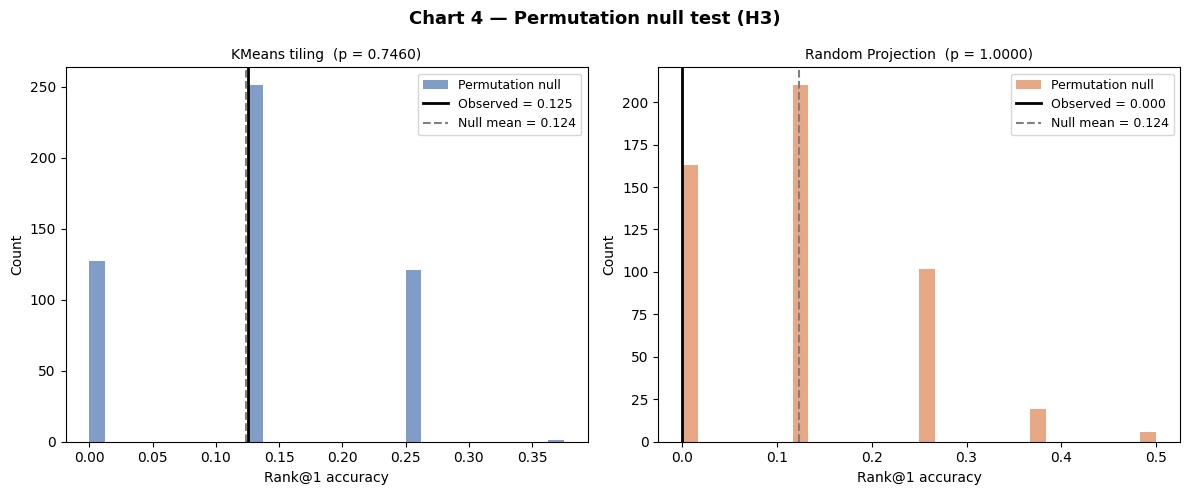

In [21]:
# ── Chart 4: Permutation null ─────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))
fig4.suptitle("Chart 4 — Permutation null test (H3)", fontsize=13, fontweight="bold")

for ax, null_arr, obs, label, col in zip(
        axes4,
        [null_km, null_rp],
        [rank1_acc, rank1_acc_rp],
        ["KMeans tiling", "Random Projection"],
        ["#4C72B0", "#DD8452"]):
    ax.hist(null_arr, bins=30, color=col, alpha=0.7, label="Permutation null")
    ax.axvline(obs, color="black", lw=2.0, ls="-", label=f"Observed = {obs:.3f}")
    ax.axvline(null_arr.mean(), color="gray", lw=1.5, ls="--",
               label=f"Null mean = {null_arr.mean():.3f}")
    p_val = (null_arr >= obs).mean()
    ax.set_title(f"{label}  (p = {p_val:.4f})", fontsize=10)
    ax.set_xlabel("Rank@1 accuracy"); ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
save_fig(fig4, "c4_permutation_null")
plt.show()

In [ ]:
# ── Chart 5: Cross-encoder stability ─────────────────────────────────
fig5, ax5 = plt.subplots(figsize=(10, 5))

x5 = np.arange(N_FIELDS)
ax5.bar(x5, same_wd, color="#55A868", alpha=0.85, label="Same-field (cross-encoder)")
ax5.axhline(cross_wd.mean(), color="#DD8452", lw=2, ls="--",
            label=f"Mean cross-field W = {cross_wd.mean():.4f}")
for xi, fname, wd in zip(x5, FIELD_NAMES, same_wd):
    ax5.text(xi, wd + 0.003, f"{wd:.3f}", ha="center", va="bottom", fontsize=8)
ax5.set_xticks(x5); ax5.set_xticklabels(FIELD_NAMES, rotation=30, ha="right", fontsize=9)
ax5.set_ylabel("Wasserstein-1 distance")
ax5.set_title("Chart 5 — Cross-encoder fingerprint stability (H4)"
              "Same-field W (green) should be below mean cross-field W (dashed)",
              fontsize=11, fontweight="bold")
ax5.legend(fontsize=9)
plt.tight_layout()
save_fig(fig5, "c5_cross_encoder")
plt.show()

SyntaxError: unterminated string literal (detected at line 12) (361021987.py, line 12)

## 12  Mechanistic digest

In [ ]:
print("=" * 70)
print(" MECHANISTIC DIGEST — λ-Distribution Fingerprinting")
print("=" * 70)
print(f"  Model (primary):  {SOURCE}")
print(f"  Model (secondary):{SOURCE2}")
print(f"  Vocabulary:       {N_ITEMS} concepts across {N_FIELDS} fields")
print(f"  Polysemous probes:{len(POLYSEMOUS)} held-out words")
print()

print("H1 — Fingerprint distinctiveness")
print(f"  Mean off-diagonal Wasserstein: {W_mat[W_mat>0].mean():.4f}")
n_sig = (KS_pval[KS_pval > 0] < 0.05).sum()
print(f"  KS significant pairs (p<0.05): {n_sig}/{N_FIELDS*(N_FIELDS-1)}")
print(f"  → H1 {'SUPPORTED' if n_sig > N_FIELDS*(N_FIELDS-1)*0.5 else 'WEAK'}")
print()

print("H2 — Best-match subspace retrieval")
print(f"  KMeans   Rank@1={rank1_acc:.3f}   Rank@3={rank3_acc:.3f}")
print(f"  RandProj Rank@1={rank1_acc_rp:.3f}   Rank@3={rank3_acc_rp:.3f}")
h2_ok = rank1_acc > 0.3 or rank1_acc_rp > 0.3
print(f"  → H2 {'SUPPORTED' if h2_ok else 'WEAK'}")
print()

print("H3 — Above-chance fingerprint matching")
print(f"  KMeans   p={p_km:.4f}  null_mean={null_km.mean():.3f}  observed={rank1_acc:.3f}")
print(f"  RandProj p={p_rp:.4f}  null_mean={null_rp.mean():.3f}  observed={rank1_acc_rp:.3f}")
h3_ok = p_km < 0.05 or p_rp < 0.05
print(f"  → H3 {'SUPPORTED' if h3_ok else 'NOT SUPPORTED at p<0.05'}")
print()

print("H4 — Cross-encoder stability")
print(f"  Same-field W (mean):  {same_wd.mean():.4f}")
print(f"  Cross-field W (mean): {cross_wd.mean():.4f}")
print(f"  Fields where same < cross mean: {rank_stability:.3f}")
print(f"  → H4 {'SUPPORTED' if rank_stability >= 0.6 else 'WEAK — check synthetic fallback'}")
print()

print("Honest caveats")
print("  · KMeans tiling imposes hard boundaries — real subspaces may overlap.")
print("  · RP tiles depend on random seed; stability improves with more trials.")
print("  · Single-word vocabulary (n=20/field) limits fingerprint resolution.")
print("  · Synthetic fallback may inflate H4 — re-run with real encoders.")
print("  · Next step: extend to sentence-level corpora for richer fingerprints.")

## 13  Future directions / backlog

| Notebook | Capability |
|----------|-----------|
| NB-05a | **Sentence-level fingerprinting** — replace single words with 50-sentence paragraphs per field; richer histograms, more stable fingerprints |
| NB-05b | **Soft subspace search** — replace hard KMeans cells with soft Gaussian mixture components; continuous match scores |
| NB-05c | **Multi-scale fingerprinting** — compute λ at multiple α (taumode) values; fingerprint becomes a 2-D surface over (α, λ) |
| NB-05d | **Inverse problem** — given an unlabelled subspace, retrieve its closest field label; deploy as a zero-shot field classifier |
| NB-05e | **Cross-layer tracking** — for transformer models, repeat fingerprinting per layer; track when fields crystallise |
| NB-05f | **KL divergence search** — replace Wasserstein with a KL-divergence-guided search to exploit the histogram structure directly |

---
Sources: ArrowSpace paper · `arrowspace` on PyPI · Anthropic *Mapping the Mind of a Large Language Model*  
Model: all-MiniLM-L6-v2 (primary) · all-mpnet-base-v2 (secondary)